# 

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#데이터-불러오기" data-toc-modified-id="데이터-불러오기-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>데이터 불러오기</a></span></li><li><span><a href="#데이터-전처리하기" data-toc-modified-id="데이터-전처리하기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>데이터 전처리하기</a></span><ul class="toc-item"><li><span><a href="#컬럼-삭제하기" data-toc-modified-id="컬럼-삭제하기-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>컬럼 삭제하기</a></span></li><li><span><a href="#결측값-처리하기" data-toc-modified-id="결측값-처리하기-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>결측값 처리하기</a></span><ul class="toc-item"><li><span><a href="#사용장소,-주소" data-toc-modified-id="사용장소,-주소-2.2.1"><span class="toc-item-num">2.2.1&nbsp;&nbsp;</span>사용장소, 주소</a></span></li><li><span><a href="#사용시간" data-toc-modified-id="사용시간-2.2.2"><span class="toc-item-num">2.2.2&nbsp;&nbsp;</span>사용시간</a></span></li><li><span><a href="#집행대상" data-toc-modified-id="집행대상-2.2.3"><span class="toc-item-num">2.2.3&nbsp;&nbsp;</span>집행대상</a></span></li></ul></li><li><span><a href="#집행대상-컬럼" data-toc-modified-id="집행대상-컬럼-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>집행대상 컬럼</a></span></li><li><span><a href="#컬럼의-데이터-형식-바꿔주기" data-toc-modified-id="컬럼의-데이터-형식-바꿔주기-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>컬럼의 데이터 형식 바꿔주기</a></span></li><li><span><a href="#사용장소-이름-바꿔주기" data-toc-modified-id="사용장소-이름-바꿔주기-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>사용장소 이름 바꿔주기</a></span></li><li><span><a href="#주소-통일해주기" data-toc-modified-id="주소-통일해주기-2.6"><span class="toc-item-num">2.6&nbsp;&nbsp;</span>주소 통일해주기</a></span></li><li><span><a href="#피벗테이블-다시-만들어서-확인하기" data-toc-modified-id="피벗테이블-다시-만들어서-확인하기-2.7"><span class="toc-item-num">2.7&nbsp;&nbsp;</span>피벗테이블 다시 만들어서 확인하기</a></span></li></ul></li><li><span><a href="#구글맵으로-위도,-경도-추가하기" data-toc-modified-id="구글맵으로-위도,-경도-추가하기-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>구글맵으로 위도, 경도 추가하기</a></span><ul class="toc-item"><li><span><a href="#관악구청에서의-거리-추가하기" data-toc-modified-id="관악구청에서의-거리-추가하기-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>관악구청에서의 거리 추가하기</a></span></li></ul></li></ul></div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-whitegrid')
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import folium
from tqdm.notebook import tqdm

In [3]:
plt.rc('font', size=13)

# 한글 폰드 문제 해결
import platform
path = "c:/Windows/Fonts/malgun.ttf"
from matplotlib import font_manager, rc


if platform.system() == 'Darwin':
    rc('font', family = 'AppleGothic')
elif platform.system() == 'Windows':
        font_name = font_manager.FontProperties(fname=path).get_name()
        rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~')

## 데이터 불러오기

In [4]:
df = pd.read_csv('../data/관악구/2019/2019 관악구 업무추진비.csv')
df.head()

,연번,사용자,사용일시,사용시간,사용금액,사용장소,주소,사용방법,사용내역,집행대상
0,1,의장,2019-01-02,08:44,58500,완산정,서울 관악구 봉천로 484,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 9명
1,2,의장,2019-01-02,12:36,89000,제주은갈치,서울 관악구 관악로 139,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 7명
2,3,의장,2019-01-04,12:53,14000,아리차이,서울 관악구 신림동길 4,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 2명
3,4,의장,2019-01-09,12:33,77000,남원추어탕,서울 관악구 쑥고개로 135,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 7명
4,5,의장,2019-01-09,14:48,83300,카페베네,서울 관악구 남부순환로 2082-29,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 17명


## 데이터 전처리하기
* 불필요한 컬럼 지우기
* 결측값 확인하기
* 불필요한 문자 지우기
* 날짜 데이터는 날짜로 형식 바꿔주기
* 숫자 데이터는 숫자로 형식 바꿔주기
* 필요한 컬럼 추가하기

In [5]:
df.shape, df.columns

((2004, 10),
 Index(['연번', '사용자', '사용일시', '사용시간', '사용금액', '사용장소', '주소', '사용방법', '사용내역',
        '집행대상'],
       dtype='object'))

In [6]:
# 컬럼 순서 보기좋게 정렬하기
df = df[['사용일시', '사용시간', '사용장소', '주소',  '사용금액', '사용자', '집행대상', '사용내역', '사용방법', '연번']]
df.head(3)

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법,연번
0,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드,1
1,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드,2
2,2019-01-04,12:53,아리차이,서울 관악구 신림동길 4,14000,의장,의장 등 2명,의정활동 및 의회운영 관련 업무휴대경비,신용카드,3


### 컬럼 삭제하기

In [7]:
# 연번 컬럼 삭제
del df['연번']
df.head()

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
0,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
1,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
2,2019-01-04,12:53,아리차이,서울 관악구 신림동길 4,14000,의장,의장 등 2명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
3,2019-01-09,12:33,남원추어탕,서울 관악구 쑥고개로 135,77000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
4,2019-01-09,14:48,카페베네,서울 관악구 남부순환로 2082-29,83300,의장,의장 등 17명,의정활동 및 의회운영 관련 업무휴대경비,신용카드


### 결측값 처리하기

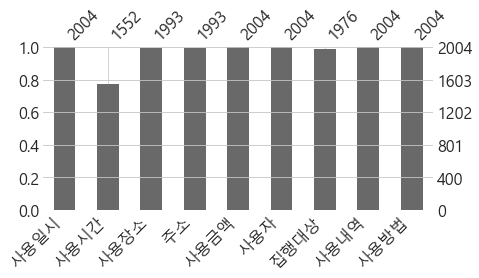

In [8]:
# 먼저 결측값 얼마나 있는지 확인해보기
import missingno as msno
msno.bar(df, figsize=(7, 3))
plt.show()

* 사용시간에서 452개
* 사용장소와, 주소에서 11개
* 집행대상에서 28개가 빠져있다.

#### 사용장소, 주소

In [9]:
# 사용장소가 nan인 데이터 확인하기
df[df['사용장소'].isnull()]

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
8,2019-01-11,NaN,NaN,NaN,50000,의장,안OO 주무관,의회운영 경조사비 지출,현금
215,2019-03-25,NaN,NaN,NaN,50000,의장,김OO 주무관 빙부상 경조사금,의장 의회운영업무추진비 경조사비 지출,현금
370,2019-04-26,NaN,NaN,NaN,1200000,관악구의회,재해구호협회,강원도 산불 피해지원 성금 납부,현금
705,2019-08-16,NaN,NaN,NaN,50000,의장,관악구의회 의원,의장 의회운영업무추진비 경조사비,현금
907,2019-10-18,NaN,NaN,NaN,50000,의장,사무국 직원 1명,의장 의회운영업무추진비 경조사비 지출,현금
996,2019-11-01,NaN,NaN,NaN,50000,의장,의원 1명,의회운영업무추진비 경조사비,현금
1176,2019-01-11,NaN,NaN,NaN,50000,의회사무국,안OO 주무관,기관운영 경조사비 지출,현금
1312,2019-03-25,NaN,NaN,NaN,50000,의회사무국,김OO 주무관 빙부상 경조사금,기관운영 업무추진비 경조사비 지출,현금
1627,2019-08-16,NaN,NaN,NaN,50000,의회사무국,관악구의회 의원,기관운영업무추진비 경조사비,현금
1782,2019-10-18,NaN,NaN,NaN,50000,의회사무국,의회사무국 직원,기관운영업무추진비 경조사비 지출,현금


In [10]:
len(df[df['사용장소'].isnull()])

11

In [11]:
df = df[df['사용방법']!='현금']
df

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
0,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
1,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
2,2019-01-04,12:53,아리차이,서울 관악구 신림동길 4,14000,의장,의장 등 2명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
3,2019-01-09,12:33,남원추어탕,서울 관악구 쑥고개로 135,77000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
4,2019-01-09,14:48,카페베네,서울 관악구 남부순환로 2082-29,83300,의장,의장 등 17명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
...,...,...,...,...,...,...,...,...,...
1999,2019-12-27,20:27,시골집,서울 관악구 낙성대로 22-7,132000,의회사무국,사무국장 등 10명,의정업무 추진관계자 간담회,신용카드
2000,2019-12-30,13:00,만리장성,서울 관악구 관악로 146,220000,의회사무국,의정팀장 등 10명,사무국 직원 격려,신용카드
2001,2019-12-30,13:08,쌈마을,서울 관악구 남부순환로226길 31,87000,의회사무국,의사팀 직원 10명,의사팀 업무추진 관련 간담회비,신용카드
2002,2019-12-30,14:01,장보고마트,서울 관악구 남부순환로230길,174000,의회사무국,"의원, 직원, 방문민원인 등",부서운영 물품(음료) 구입,신용카드


* 사용방법에서 현금으로 사용한 데이터가 사용장소와 주소의 결측치이다.
* 현금으로 사용한 금액은 총 170만원이고, 강원도 산불 성금에 120만원, 경조사비로 50만원이 지출됐다.
* 사용방법이 카드인 것만 보자

#### 사용시간

In [12]:
# 사용시간 결측치 처리하기
indexes = df[df.사용시간.isnull()].index
indexes

Int64Index([1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160,
            ...
            1584, 1585, 1586, 1587, 1588, 1589, 1590, 1591, 1592, 1593],
           dtype='int64', length=441)

In [13]:
for index in indexes:
    df.loc[index, '사용시간'] = '00:00'

In [14]:
df[df.사용시간.isnull()]

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법


* 사용시간은 사용일시의 참고자료쯤 되는 컬럼이기 때문에 결측치에 00:00을 넣어준다.

#### 집행대상

In [15]:
df[df['집행대상'].isnull()]

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
1276,2019-03-07,00:00,다이소,서울 관악구 남부순환로 1840,17500,의회사무국,NaN,부서운영 필요 물품 구입,신용카드
1335,2019-04-04,00:00,진진식품,서울 관악구 난곡로 168,260000,의회사무국,NaN,의원 워크숍 사전준비 간식류 구입,신용카드
1368,2019-04-16,00:00,장보고마트,서울 관악구 남부순환로230길,195900,의회사무국,NaN,창녕군협약식 추진관련 간담회 다과 및 행사용품 구입,신용카드
1369,2019-04-16,00:00,다이소,서울 강남구 남부순환로 2748,6000,의회사무국,NaN,창녕군협약식 행사관련 종이컵 구매,신용카드
1370,2019-04-16,00:00,파리바게뜨,서울 관악구 봉천동,39100,의회사무국,NaN,창녕군협약식 추진관련 간담회 다과 구입,신용카드
1371,2019-04-16,00:00,김가네,서울 관악구 관악로 152,48000,의회사무국,NaN,창녕군협약식 참석 의원 및 수행직원 조식 구매,신용카드
1392,2019-04-26,00:00,장보고마트,서울 관악구 남부순환로230길,271500,의회사무국,NaN,강릉기관방문 관련 다과 및 행사용품 구입,신용카드
1393,2019-04-26,00:00,다이소,서울 강남구 남부순환로 2748,4000,의회사무국,NaN,강릉기관방문 행사관련 종이컵 구매,신용카드
1394,2019-04-26,00:00,태창약국,서울 관악구 쑥고개로 126-1,84000,의회사무국,NaN,강릉기관 방문 관련 비상약품 구매,신용카드
1459,2019-05-22,00:00,롯데리아（백령도점）,서울시 중구 세종대로 39,172600,의회사무국,NaN,의원워크숍 군부대 안보교육 관련 장병 위문간식 구매,신용카드


In [16]:
df.isnull().sum()

사용일시     0
사용시간     0
사용장소     0
주소       0
사용금액     0
사용자      0
집행대상    28
사용내역     0
사용방법     0
dtype: int64

In [17]:
df[df['집행대상'].isnull()].사용금액.sum()

3791480

In [18]:
# 결측치 제거하기
df.dropna(inplace=True)
df

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
0,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
1,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
2,2019-01-04,12:53,아리차이,서울 관악구 신림동길 4,14000,의장,의장 등 2명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
3,2019-01-09,12:33,남원추어탕,서울 관악구 쑥고개로 135,77000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
4,2019-01-09,14:48,카페베네,서울 관악구 남부순환로 2082-29,83300,의장,의장 등 17명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
...,...,...,...,...,...,...,...,...,...
1999,2019-12-27,20:27,시골집,서울 관악구 낙성대로 22-7,132000,의회사무국,사무국장 등 10명,의정업무 추진관계자 간담회,신용카드
2000,2019-12-30,13:00,만리장성,서울 관악구 관악로 146,220000,의회사무국,의정팀장 등 10명,사무국 직원 격려,신용카드
2001,2019-12-30,13:08,쌈마을,서울 관악구 남부순환로226길 31,87000,의회사무국,의사팀 직원 10명,의사팀 업무추진 관련 간담회비,신용카드
2002,2019-12-30,14:01,장보고마트,서울 관악구 남부순환로230길,174000,의회사무국,"의원, 직원, 방문민원인 등",부서운영 물품(음료) 구입,신용카드


In [19]:
# 인덱스 다시 정리해주기
df.index = range(len(df))
df

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
0,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
1,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
2,2019-01-04,12:53,아리차이,서울 관악구 신림동길 4,14000,의장,의장 등 2명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
3,2019-01-09,12:33,남원추어탕,서울 관악구 쑥고개로 135,77000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
4,2019-01-09,14:48,카페베네,서울 관악구 남부순환로 2082-29,83300,의장,의장 등 17명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
...,...,...,...,...,...,...,...,...,...
1960,2019-12-27,20:27,시골집,서울 관악구 낙성대로 22-7,132000,의회사무국,사무국장 등 10명,의정업무 추진관계자 간담회,신용카드
1961,2019-12-30,13:00,만리장성,서울 관악구 관악로 146,220000,의회사무국,의정팀장 등 10명,사무국 직원 격려,신용카드
1962,2019-12-30,13:08,쌈마을,서울 관악구 남부순환로226길 31,87000,의회사무국,의사팀 직원 10명,의사팀 업무추진 관련 간담회비,신용카드
1963,2019-12-30,14:01,장보고마트,서울 관악구 남부순환로230길,174000,의회사무국,"의원, 직원, 방문민원인 등",부서운영 물품(음료) 구입,신용카드


* 집행대상에서 null인 값의 총 사용금액은 3,791,480이다.
* 주로 행사 다과나 준비물품 또는 부서 운영 필요 물품을 구매했다.

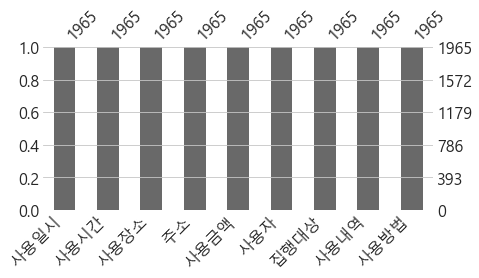

In [20]:
msno.bar(df, figsize=(7, 3))
plt.show()

### 집행대상 컬럼
* 일단 보류

### 컬럼의 데이터 형식 바꿔주기
* 사용일시, 사용시간의 데이터 타입을  date로 바꿔주자

In [21]:
# 일단 확인부터!
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965 entries, 0 to 1964
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용일시    1965 non-null   object
 1   사용시간    1965 non-null   object
 2   사용장소    1965 non-null   object
 3   주소      1965 non-null   object
 4   사용금액    1965 non-null   int64 
 5   사용자     1965 non-null   object
 6   집행대상    1965 non-null   object
 7   사용내역    1965 non-null   object
 8   사용방법    1965 non-null   object
dtypes: int64(1), object(8)
memory usage: 138.3+ KB


* 현재 사용일시와 사용시간의 데이터 타입은 문자열 타입이다!
* 날짜 타입으로 변경해주자!

In [22]:
# to_datetime을 이용해서 변경해준다.
df['사용일시'] = pd.to_datetime(df['사용일시'])

In [23]:
# 잘 변경되었는지 확인해준다!
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965 entries, 0 to 1964
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   사용일시    1965 non-null   datetime64[ns]
 1   사용시간    1965 non-null   object        
 2   사용장소    1965 non-null   object        
 3   주소      1965 non-null   object        
 4   사용금액    1965 non-null   int64         
 5   사용자     1965 non-null   object        
 6   집행대상    1965 non-null   object        
 7   사용내역    1965 non-null   object        
 8   사용방법    1965 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 138.3+ KB


In [24]:
# 사용시간도 변경이 가능할까?
pd.to_datetime(df['사용시간'])
# 시간만 날짜타입으로 변경했을 때, 오늘 날짜가 들어간다.
# 크게 의미가 있진 않음

0      2020-10-28 08:44:00
1      2020-10-28 12:36:00
2      2020-10-28 12:53:00
3      2020-10-28 12:33:00
4      2020-10-28 14:48:00
               ...        
1960   2020-10-28 20:27:00
1961   2020-10-28 13:00:00
1962   2020-10-28 13:08:00
1963   2020-10-28 14:01:00
1964   2020-10-28 20:24:00
Name: 사용시간, Length: 1965, dtype: datetime64[ns]

In [25]:
# 날짜를 기준으로 정렬하기
df.sort_values(by='사용일시', inplace=True)
df

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
26,2019-01-01,20:57,바로수제햄부대찌개,서울 관악구 봉천로 378,39000,부의장,부의장 등 5명,의회운영 및 의정활동 관련 업무 유대경비,신용카드
0,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
1,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
69,2019-01-02,20:43,고향순대국,서울 영등포구 디지털로 373,31000,행정재경위원장,행정재경위원장 등 4명,의정활동 및 상임위 관련 업무 간담회,신용카드
1147,2019-01-02,00:00,모비딕커피,서울 관악구 관악로 144,20000,의회사무국,보건복지전문위원 등 4명,의안 자료연구 및 검토 간담회,신용카드
...,...,...,...,...,...,...,...,...,...
1962,2019-12-30,13:08,쌈마을,서울 관악구 남부순환로226길 31,87000,의회사무국,의사팀 직원 10명,의사팀 업무추진 관련 간담회비,신용카드
1963,2019-12-30,14:01,장보고마트,서울 관악구 남부순환로230길,174000,의회사무국,"의원, 직원, 방문민원인 등",부서운영 물품(음료) 구입,신용카드
1100,2019-12-30,12:51,제주은갈치,서울 관악구 관악로 139,1000,의장,의장 외 4명,의정활동 및 의회운영 관련 업무유대경비,신용카드
1101,2019-12-30,12:53,제주은갈치,서울 관악구 관악로 139,60000,의장,의장 외 4명,의정활동 및 의회운영 관련 업무유대경비,신용카드


In [26]:
# 인덱스 정리하기
df.index = range(len(df))
df

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
0,2019-01-01,20:57,바로수제햄부대찌개,서울 관악구 봉천로 378,39000,부의장,부의장 등 5명,의회운영 및 의정활동 관련 업무 유대경비,신용카드
1,2019-01-02,08:44,완산정,서울 관악구 봉천로 484,58500,의장,의장 등 9명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
2,2019-01-02,12:36,제주은갈치,서울 관악구 관악로 139,89000,의장,의장 등 7명,의정활동 및 의회운영 관련 업무휴대경비,신용카드
3,2019-01-02,20:43,고향순대국,서울 영등포구 디지털로 373,31000,행정재경위원장,행정재경위원장 등 4명,의정활동 및 상임위 관련 업무 간담회,신용카드
4,2019-01-02,00:00,모비딕커피,서울 관악구 관악로 144,20000,의회사무국,보건복지전문위원 등 4명,의안 자료연구 및 검토 간담회,신용카드
...,...,...,...,...,...,...,...,...,...
1960,2019-12-30,13:08,쌈마을,서울 관악구 남부순환로226길 31,87000,의회사무국,의사팀 직원 10명,의사팀 업무추진 관련 간담회비,신용카드
1961,2019-12-30,14:01,장보고마트,서울 관악구 남부순환로230길,174000,의회사무국,"의원, 직원, 방문민원인 등",부서운영 물품(음료) 구입,신용카드
1962,2019-12-30,12:51,제주은갈치,서울 관악구 관악로 139,1000,의장,의장 외 4명,의정활동 및 의회운영 관련 업무유대경비,신용카드
1963,2019-12-30,12:53,제주은갈치,서울 관악구 관악로 139,60000,의장,의장 외 4명,의정활동 및 의회운영 관련 업무유대경비,신용카드


### 사용장소 이름 바꿔주기
* 먼저 pivot table을 이용해서 사용장소 중 같은 장소이지만 다른 장소로 표시된 것들을 파악하자!

In [27]:
# 먼저 파악할 피벗테이블 만들어주기
pt1 = pd.pivot_table(df, index=['사용장소'], aggfunc=np.sum).reset_index()
pt1

,사용장소,사용금액
0,#207,27200
1,(주)소명생고기,100000
2,(주)송원마포갈비,45500
3,(주)신세계페이먼츠,546290
4,(주)신화아이푸드,469500
...,...,...
597,흥부보쌈,1167000
598,희로애락,508000
599,희전명가,88000
600,히포커피,10800


In [28]:
for name in pt1['사용장소'].unique():
    print(name)

#207
(주)소명생고기
(주)송원마포갈비
(주)신세계페이먼츠
(주)신화아이푸드
(주)영풍안성상휴게
11번가
406CAFE
ENZO(엔조)
GS슈퍼
GS슈퍼마켓
KFC
KSNET
SEROTONIN
SOME801
㈜배다리문화원
가마솥
가마솥삼계탕
가빈
가야촌오리주물럭
가야촌유황오리
가온매운갈비찜
가츠몽
감격시대
감나무집
값진식육
강강술래
강강술래신림본동점
강남식당
강문어화횟집
강촌민물매운탕2호점
강촌민물매운탕２호점
개성보쌈
갯바위
갯벌낙지
거목쟁반짜장
경복궁
경식이네알쌈쭈꾸미
고기만족
고기킹
고려왕족발
고봉민김밥
고봉민김밥인
고창복의낙지세상
고향순대국
고향식당
고흥식당
광명수산
광어삼촌
교대전집
교동왕족발
교촌치킨
구름산원주추어탕
구수옥설렁탕
국내산생고기
국회루
굴러들어온복
그린파크식당
금비
금수강산
금수사
기사님식당
기장산곰장어포차
기절초풍왕순대
김가네
김가네 관악구청점
김밥
김밥천국
김밥＆백반
김용해순대국
김채원24시감자탕
깡돈
꽃올림
꿀벌식당
나의집
나주곰탕
나주오리종가
낙성푸줏간
낙지마을해물구이
낙지촌
난곡문성파리바게뜨
난곡사거리 파리바게뜨
남궁야
남도식당
남도전문음식점
남도해물요리전문점
남원추어탕
낭만모로코
내자리에프씨카페
너구리칼국수
노가리7080
농장사람들
다락방
다리목
다빈
다온죽카페
다우데이타
다이소
달구리
당곡기사식당
당진강완옥아귀찜
당진아구동태찜탕
대가한방오리
대박수산
대주직판장
대호아구집
더고기서울대맛집
더블미트 봉천점
더진국
던킨도너츠
도일각
돈가대박집
돌체
동강염소탕
동강영양탕
동경산책
동원각
동태찜&코다리냉면
동해
동해물회
동해세꼬시
동해수산
동해안횟집
두꺼비맛집
두꺼비황소곱창
두부이야기
두부이야기봉천점
들향기칼국수쭈꾸미
등갈비연탄구이
등촌샤브칼국수
딸랏롯빠이
떡보의하루
또와봐순대
뚱띵이곱창
뚱띵이왕갈비
라온
라티놀
라페리체
란
런던부페
려
리몽
마노아숯불구이
마늘오리
마당쇠
마야
마을부엌어울림
마켓동광
마포소금구이
마포숯불갈비
만다린
만두와김밥
만리성
만리장성
만양순대국소머리국밥
맘스터치
맘씨커피
맛고을칼국수＆찰보리
맛고을칼국수＆찰보

* 확인해봐야 할 이름 비슷한 곳들
    * 가마솥, 가마솥삼계탕
    * 가야촌오리주물럭, 가야촌유황오리
    * 강강술래, 강강술래신림본동점
    * 강촌민물매운탕2호점, 강촌민물매운탕２호점
    * 고봉민김밥, 고봉민김밥인
    * 고향순대국, 고향식당
    * 김가네, 김가네 관악구청점
    * 김밥, 김밥천국, 김밥＆백반
    * 남도식당, 남도전문음식점, 남도해물요리전문점
    * 동강염소탕, 동강영양탕
    * 동해, 동해물회, 동해세꼬시, 동해수산, 동해안횟집
    * 두꺼비맛집, 두꺼비황소곱창
    * 두부이야기, 두부이야기봉천점
    * 뚱띵이곱창, 뚱띵이왕갈비
    * 마포소금구이, 마포숯불갈비
    * 만리성, 만리장성
    * 맛고을칼국수＆찰보리, 맛고을칼국수＆찰보리밥
    * 먹쉬돈나, 먹쉬돈나 서울대역점
    * 명가진곰탕, 명가쭈꾸미코다리
    * 명태어장, 명태어장(서울대점)
    * 명품청기와감자탕, 명품청기와감자탕미성점
    * 모리, 모리돈부리
    * 목포낙지홍어 ,목포부부아구찜 ,목포산낙지철판해물 ,목포수산, 목포아구찜, 목포홍탁, 무교동갯벌낚지, 무교동본낙지
    * 미가정맑은곰탕, 미가할매집, 미가할매참품한우
    * 바우네나주곰탕, 바우네나주곰탕　봉천
    * 병천순대 , 병천순대국
    * 본죽, 본죽 관악구청점, 본죽&본도시락, 본죽&비빔밥, 본죽봉천점, 본죽＆비빔밥, 본죽＆비빔밥ｃａｆｅ
    * 봉이 구이대장, 봉이구이대장
    * 사시사철흑염소.오리, 사시사철흑염소오리
    * 삼미옥, 삼미칼국수
    * 삼백돈, 삼백돈돈가츠
    * 서울대학교생협호암교수회관, 서울대학교생활협동조
    * 소담밥상, 소담촌
    * 숙이네생선구이, 숙이네조개전골
    * 스타벅스, 스타벅스 서울대입구역점
    * 아웃백, 아웃백스테이크
    * 양평서울해장국, 양평해장국
    * 얼큰수제비, 얼큰수제비 해물칼국수, 얼큰수제비해물칼국수
    * 엔조 파스타&피자, 엔조파스타&피자
    * 옥천골, 옥천민물매운탕
    * 이가네감자탕, 이가네바지락칼국수
    * 이대감명품막창, 이대감왕족발
    * 일커피, 일커피 서울대입구점, 일커피　서울대입구점
    * 자연별곡, 자연별곡 서울대입구점, 자연별곡서울대입구점
    * 작은따옴표 협동조합, 작은따옴표협동조합
    * 장수삼계탕, 장수집, 장수생삼겹살, 장수촌, 장수촌풍천장어
    * 전주민속촌, 전주전집, 전주집, 전주콩나물국밥
    * 정가, 정가네, 정가네감자탕＆부대찌, 정가네왕갈비탕
    * 정담, 정담은보쌈
    * 종가집, 종가할머니보쌈, 종로계림닭도리탕, 종로계림닭도리탕원조
    * 진부령　황태촌, 진부령황태촌
    * 진우리독도참치, 진우리참치
    * 카페모아, 카페모아관악구청점
    * 커피빈, 커피빈코리아, 커피빈코리아인
    * 콩심, 콩심 서울대점, 콩심서울대점
    * 쿠팡, 쿠팡㈜
    * 태창약국, 태창온누리약국
    * 태평양출장부페, 태평양킹참치
    * 투썸서울대입구역, 투썸플레이스
    * 파리바게뜨, 파리바게뜨서울대입구, 파리바게트 
    * 난곡문성파리바게뜨, 난곡사거리 파리바게뜨, 서울대 파리바게뜨, 서울대입구역2호 파리바게뜨, 은천길입구 파리바게뜨
    * 풍년갈비, 풍년식당, 풍년오리, 풍년옥, 풍년집
    * 행복포차, 행운포차
    * 봉천함흥냉면, 함흥냉면
    * 영광수산장어1번가, 영광수산장어１번가









* 여기는 뭘까?
    * 대주직판장
    * 내자리에프씨카페
    * 다우데이타
    * 밋앤미트
    * 브라더
    * 블리스
    * 비알코리아
    * 빅히트물류
    * 산책
    * 세인트존스호텔
    * 세컨드페이지
    * 신세계페이먼츠
    * 에스엠씨
    * 올림반찬
    * 옷살
    * 와사비
    * 우아한형제들
    * 위메프
    * 죠아찌쥬스, 쥬스를만드는지금
    * 청주블루가든
    * Ｇ마켓




In [29]:
df[df['사용장소']=='시골집영양탕삼계탕']

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법


In [30]:
# 사용장소 파리바게트의 이름을 파리바게뜨로 변경
for row in df.index:
    
    # 파리바게뜨
    if (df.loc[row, '사용장소'] == '파리바게트') or (df.loc[row, '사용장소'] == '난곡문성파리바게뜨') or (df.loc[row, '사용장소'] == '난곡사거리 파리바게뜨'):
        df.loc[row, '사용장소'] = '파리바게뜨'
        
    elif (df.loc[row, '사용장소'] == '서울대 파리바게뜨') or (df.loc[row, '사용장소'] == '서울대입구역2호 파리바게뜨') or (df.loc[row, '사용장소'] == '은천길입구 파리바게뜨'):
        df.loc[row, '사용장소'] = '파리바게뜨'
    
    # GS슈퍼마켓
    elif (df.loc[row, '사용장소'] == 'GS슈퍼'):
        df.loc[row, '사용장소'] = 'GS슈퍼마켓'
        
    # 강강술래
    elif (df.loc[row, '사용장소'] == '강강술래신림본동점'):
        df.loc[row, '사용장소'] = '강강술래'
    
    # 강촌민물매운탕2호점
    elif (df.loc[row, '사용장소'] == '강촌민물매운탕２호점'):
        df.loc[row, '사용장소'] = '강촌민물매운탕2호점'
    
    # 고봉민김밥
    elif (df.loc[row, '사용장소'] == '고봉민김밥인'):
        df.loc[row, '사용장소'] = '고봉민김밥'
    
    # 김가네
    elif (df.loc[row, '사용장소'] == '김가네 관악구청점'):
        df.loc[row, '사용장소'] = '김가네'
        
    # 동강염소탕
    elif (df.loc[row, '사용장소'] == '동강영양탕'):
        df.loc[row, '사용장소'] = '동강염소탕'
    
    # 두부이야기
    elif (df.loc[row, '사용장소'] == '두부이야기봉천점'):
        df.loc[row, '사용장소'] = '두부이야기'
                
    # 맛고을칼국수＆찰보리밥
    elif (df.loc[row, '사용장소'] == '맛고을칼국수＆찰보리'):
        df.loc[row, '사용장소'] = '맛고을칼국수＆찰보리밥'
        
    # 명태어장
    elif (df.loc[row, '사용장소'] == '명태어장(서울대점)'):
        df.loc[row, '사용장소'] = '명태어장'
        
    # 명품청기와감자
    elif (df.loc[row, '사용장소'] == '명품청기와감자탕미성점'):
        df.loc[row, '사용장소'] = '명품청기와감자탕'
        
    # 미가할매집
    elif (df.loc[row, '사용장소'] == '미가할매참품한우'):
        df.loc[row, '사용장소'] = '미가할매집'
        
    # 바우네나주곰탕
    elif (df.loc[row, '사용장소'] == '바우네나주곰탕　봉천'):
        df.loc[row, '사용장소'] = '바우네나주곰탕'
        
    # 본죽    
    elif (df.loc[row, '사용장소'] == '본죽 관악구청점') or (df.loc[row, '사용장소'] == '본죽&본도시락') or (df.loc[row, '사용장소'] == '본죽&비빔밥'):
        df.loc[row, '사용장소'] = '본죽'
        
    elif (df.loc[row, '사용장소'] == '본죽봉천점') or (df.loc[row, '사용장소'] == '본죽＆비빔밥') or (df.loc[row, '사용장소'] == '본죽＆비빔밥ｃａｆｅ'):
        df.loc[row, '사용장소'] = '본죽'
        
    # 봉이구이대장
    elif (df.loc[row, '사용장소'] == '봉이 구이대장'):
        df.loc[row, '사용장소'] = '봉이구이대장'
        
    # 사시사철흑염소오리
    elif (df.loc[row, '사용장소'] == '사시사철흑염소.오리'):
        df.loc[row, '사용장소'] = '사시사철흑염소오리'
    
    # 삼백돈
    elif (df.loc[row, '사용장소'] == '삼백돈돈가츠'):
        df.loc[row, '사용장소'] = '삼백돈'
        
    # 서울대학교생활협동조합
    elif (df.loc[row, '사용장소'] == '서울대학교생협호암교수회관') or (df.loc[row, '사용장소'] == '서울대학교생활협동조'):
        df.loc[row, '사용장소'] = '서울대학교생활협동조합'
        
    # 스타벅스
    elif (df.loc[row, '사용장소'] == '스타벅스 서울대입구역점'):
        df.loc[row, '사용장소'] = '스타벅스'
        
    # 아웃백
    elif (df.loc[row, '사용장소'] == '아웃백스테이크'):
        df.loc[row, '사용장소'] = '아웃백'
        
    # 얼큰수제비해물칼국수
    elif (df.loc[row, '사용장소'] == '얼큰수제비') or (df.loc[row, '사용장소'] == '얼큰수제비 해물칼국수'):
        df.loc[row, '사용장소'] = '얼큰수제비해물칼국수'
        
    # 엔조파스타&피자
    elif (df.loc[row, '사용장소'] == '엔조 파스타&피자') or (df.loc[row, '사용장소'] == 'ENZO(엔조)'):
        df.loc[row, '사용장소'] = '엔조파스타&피자'
        
    # 이대감명품막창
    elif (df.loc[row, '사용장소'] == '이대감왕족발'):
        df.loc[row, '사용장소'] = '이대감명품막창'
        
    # 일커피
    elif (df.loc[row, '사용장소'] == '일커피 서울대입구점') or (df.loc[row, '사용장소'] == '일커피　서울대입구점'):
        df.loc[row, '사용장소'] = '일커피'
        
    # 자연별곡
    elif (df.loc[row, '사용장소'] == '자연별곡 서울대입구점') or (df.loc[row, '사용장소'] == '자연별곡서울대입구점'):
        df.loc[row, '사용장소'] = '자연별곡'
        
        
    # 작은따옴표
    elif (df.loc[row, '사용장소'] == '작은따옴표 협동조합') or (df.loc[row, '사용장소'] == '작은따옴표협동조합'):
        df.loc[row, '사용장소'] = '작은따옴표'
    
    # 장수집
    elif (df.loc[row, '사용장소'] == '장수삼계탕'):
        df.loc[row, '사용장소'] = '장수집'
    
    # 종로계림닭도리탕원조
    elif (df.loc[row, '사용장소'] == '종로계림닭도리탕'):
        df.loc[row, '사용장소'] = '종로계림닭도리탕원조'
        
    # 진부령황태촌
    elif (df.loc[row, '사용장소'] == '진부령　황태촌'):
        df.loc[row, '사용장소'] = '진부령황태촌'
        
    # 진우리참치
    elif (df.loc[row, '사용장소'] == '진우리독도참치'):
        df.loc[row, '사용장소'] = '진우리참치'
        
    # 카페모아
    elif (df.loc[row, '사용장소'] == '카페모아관악구청점'):
        df.loc[row, '사용장소'] = '카페모아'
        
    # 커피빈
    elif (df.loc[row, '사용장소'] == '커피빈코리아') or (df.loc[row, '사용장소'] == '커피빈코리아인'):
        df.loc[row, '사용장소'] = '커피빈'
        
    # 콩심
    elif (df.loc[row, '사용장소'] == '콩심 서울대점') or (df.loc[row, '사용장소'] == '콩심서울대점'):
        df.loc[row, '사용장소'] = '콩심'
        
    # 쿠팡
    elif (df.loc[row, '사용장소'] == '쿠팡㈜'):
        df.loc[row, '사용장소'] = '쿠팡'
        
    # 태창온누리약국
    elif (df.loc[row, '사용장소'] == '태창약국'):
        df.loc[row, '사용장소'] = '태창온누리약국'
        
    # 투썸플레이스
    elif (df.loc[row, '사용장소'] == '투썸서울대입구역'):
        df.loc[row, '사용장소'] = '투썸플레이스'
        
    # 파리바게뜨
    elif (df.loc[row, '사용장소'] == '파리바게뜨서울대입구') or (df.loc[row, '사용장소'] == '파리바게트'):
        df.loc[row, '사용장소'] = '파리바게뜨'
        
    # 풍년옥
    elif (df.loc[row, '사용장소'] == '풍년오리'):
        df.loc[row, '사용장소'] = '풍년옥'
        
    # 영광수산장어1번가
    elif (df.loc[row, '사용장소'] == '영광수산장어１번가'):
        df.loc[row, '사용장소'] = '영광수산장어1번가'

* 수기로 체크했는데 위도, 경도로 기준을 만들어서 정리한다면 좀 더 쉽게 파악할 수 있지 않을까?
* 그렇게 하려면 일단 주소까지도 일정하게 만져줘야 해

In [31]:
pd.pivot_table(df, index=['사용장소'], aggfunc=np.sum)

,사용금액
사용장소,
#207,27200
(주)소명생고기,100000
(주)송원마포갈비,45500
(주)신세계페이먼츠,546290
(주)신화아이푸드,469500
...,...
흥부보쌈,1167000
희로애락,508000
희전명가,88000


### 주소 통일해주기

In [32]:
# 사용장소로 피벗테이블
pt1 = pd.pivot_table(df, index=['사용장소'], aggfunc=np.sum).reset_index()
pt1

,사용장소,사용금액
0,#207,27200
1,(주)소명생고기,100000
2,(주)송원마포갈비,45500
3,(주)신세계페이먼츠,546290
4,(주)신화아이푸드,469500
...,...,...
542,흥부보쌈,1167000
543,희로애락,508000
544,희전명가,88000
545,히포커피,10800


* 549행

In [33]:
# 사용장소와 주소를 인덱스로 피벗테이블
pt2 = pd.pivot_table(df, index=['사용장소', '주소'], aggfunc=np.sum).reset_index()
pt2

,사용장소,주소,사용금액
0,#207,서울 관악구 원신길 128,27200
1,(주)소명생고기,서울 금천구 시흥대로 264,100000
2,(주)송원마포갈비,서울 영등포구 도림로147길 2-1,45500
3,(주)신세계페이먼츠,서울 중구 남대문시장10길 2,546290
4,(주)신화아이푸드,충청북도 청주시 서원구 1순환로 886,469500
...,...,...,...
631,흥부보쌈,서울 관악구 신림로59길 15-13,1167000
632,희로애락,서울 관악구 봉천로 465,508000
633,희전명가,서울 관악구 남부순환로180길 6,88000
634,히포커피,서울 관악구 신림로23길 21,10800


* 638행

In [34]:
# 이름은 같으면서 주소가 다른 데이터가 몇 개 있는지 파악하기
place_cnt = pt2['사용장소'].value_counts()
pt3 = pd.DataFrame(place_cnt).reset_index()
pt3.rename(columns={'index' : '사용장소', '사용장소':'cnt'}, inplace=True)
pt3

,사용장소,cnt
0,파리바게뜨,17
1,시골집,6
2,김밥천국,5
3,본죽,4
4,떡보의하루,4
...,...,...
542,목포아구찜,1
543,상도늘보리,1
544,세계로마트,1
545,새마을식당,1


In [35]:
# 합치기!!!
pt1.set_index('사용장소')
pt3.set_index('사용장소')

pt = pd.concat([pt1.set_index('사용장소'), pt3.set_index('사용장소')], axis=1).reset_index()
pt.rename(columns={'index' : '사용장소'}, inplace=True)
pt[pt['사용장소']=='파리바게뜨']

,사용장소,사용금액,cnt
499,파리바게뜨,1086200,17


In [36]:
# 주소가 두 개 이상으로 되어있는 장소들
pt[pt['cnt']>1].sort_values(by='cnt', ascending=False)
# 54개

,사용장소,사용금액,cnt
499,파리바게뜨,1086200,17
281,시골집,9381000,6
61,김밥천국,347000,5
69,나주곰탕,928500,4
214,본죽,615000,4
121,떡보의하루,3453600,4
475,콩심,540000,3
527,홍콩반점,278500,3
520,해물나라,1892000,3
391,일커피,170000,3


* 이거 이제 어떻게 수정해야할까
* 한 장소에 주소가 하나만 있는 것이 베스트!
* 프랜차이즈는 지점이 여러개라서 제외한다.
* 프랜차이즈가 아닌 곳들은 주소를 통일시켜주자!

In [37]:
pt2 = pt2.sort_values(by='주소')
pt2[pt2['사용장소']=='황제갈비']

,사용장소,주소,사용금액
618,황제갈비,서울 관악구 남부순환로 1644,235000
619,황제갈비,서울특별시 관악구 남부순환로 1644,266000


* 파리바게뜨
서울 관악구 봉천동 -> 서울 관악구 관악로 168
서울 관악구 은천로 86 -> 서울 관악구 은천로 92
서울 관악구 중앙1가길 3 -> 서울 관악구 봉천로 475
서울 영등포구 국회대로44길 10	-> 서울 영등포구 영신로 200 
서울 영등포구 영등포동7가 57 -> 서울 영등포구 영신로 200
서울특별시 관악구 난곡로 60 -> 서울 관악구 난곡로 60


* 시골집
서울 관악구 낙성대로 22-7
시골집영양탕삼계탕 첩자 발견

* 김밥천국
문제없음

* 나주곰탕
서울 관악구 신림로28길 34 -> 서울 관악구 신림로28길 30	

In [38]:
# 주소 2개 이상인 데이터 주소 하나로 통일시켜주기
for row in df.index:
    
    # 파리바게뜨
    if df.loc[row, '사용장소']=='파리바게뜨':
        if df.loc[row, '주소']=='서울 관악구 봉천동':
            df.loc[row, '주소'] = '서울 관악구 관악로 168'
            
        elif df.loc[row, '주소']=='서울 관악구 은천로 86':
            df.loc[row, '주소'] = '서울 관악구 은천로 92'
            
        elif df.loc[row, '주소']=='서울 관악구 중앙1가길 3':
            df.loc[row, '주소'] = '서울 관악구 봉천로 475'
        
        elif df.loc[row, '주소']=='서울 영등포구 국회대로44길 10':
            df.loc[row, '주소'] = '서울 영등포구 영신로 200'
            
        elif df.loc[row, '주소']=='서울 영등포구 영등포동7가 57':
            df.loc[row, '주소'] = '서울 영등포구 영신로 200'
            
        elif df.loc[row, '주소']=='서울특별시 관악구 난곡로 60':
            df.loc[row, '주소'] = '서울 관악구 난곡로 60'
            
    
    # 시골집
    elif df.loc[row, '사용장소']=='시골집':
        if df.loc[row, '주소'] == '서울 관악구 낙성대로':
            df.loc[row, '주소'] = '서울 관악구 낙성대로 22-7'
            
        elif df.loc[row, '주소'] == '서울 관악구 낙성대로':
            df.loc[row, '주소'] = '서울 관악구 낙성대로 22-8'
        
        elif df.loc[row, '주소'] == '서울 관악구 봉천로 308-2':
            df.loc[row, '사용장소'] = '시골집영양탕삼계탕'
            
    # 떡보의하루
    elif df.loc[row, '사용장소']=='떡보의하루':
        if df.loc[row, '주소'] == '서울 금천구 가산로 33범안로':
            df.loc[row, '주소'] = '서울 금천구 가산로 33'
            
        elif df.loc[row, '주소'] == '서울 금천구 가산로33':
            df.loc[row, '주소'] = '서울 금천구 가산로 33'
        
        elif df.loc[row, '주소'] == '서울 금천구 범안로':
            df.loc[row, '사용장소'] = '서울 금천구 가산로 33'
            
    
    # 콩심
    elif df.loc[row, '사용장소']=='콩심':
        if df.loc[row, '주소'] == '서울특별시 관악구 관악로 144':
            df.loc[row, '주소'] = '서울 관악구 관악로 144'
            
    
    # 홍콩반점
    elif df.loc[row, '사용장소']=='홍콩반점':
        if df.loc[row, '주소'] == '서울 관악구 관악로 125':
            df.loc[row, '주소'] = '서울 관악구 관악로 152'
            
        elif df.loc[row, '주소'] == '서울 관악구 관악로152':
            df.loc[row, '주소'] = '서울 관악구 관악로 152'
            
    # 해물나라
    elif df.loc[row, '사용장소']=='해물나라':
        if df.loc[row, '주소'] == '서울 관악구 남부순환로':
            df.loc[row, '주소'] = '서울 관악구 남부순환로 1674'
            
        elif df.loc[row, '주소'] == '서울 관악구 호암로 588':
            df.loc[row, '사용장소'] = '해물나라곤드레밥'

    # 일커피
    elif df.loc[row, '사용장소']=='일커피':
        if df.loc[row, '주소'] == '서울시 관악구 쑥고개로 123':
            df.loc[row, '주소'] = '서울 관악구 쑥고개로 123'
            
        elif df.loc[row, '주소'] == '서울특별시 관악구 쑥고개로 123':
            df.loc[row, '주소'] = '서울 관악구 쑥고개로 123'

    # 한근한방삼계탕
    elif df.loc[row, '사용장소']=='한근한방삼계탕':
        if df.loc[row, '주소'] == '서울 관악구 봉천동':
            df.loc[row, '주소'] = '서울 관악구 봉천로 396'
            
        elif df.loc[row, '주소'] == '서울 관악구 봉천동 396':
            df.loc[row, '주소'] = '서울 관악구 봉천로 396'
            
            
    # 만리장성
    elif df.loc[row, '사용장소']=='만리장성':
        if df.loc[row, '주소'] == '서울시 관악구 관악로 146':
            df.loc[row, '주소'] = '서울 관악구 관악로 146'
            
        elif df.loc[row, '주소'] == '서울특별시 관악구 관악로 146':
            df.loc[row, '주소'] = '서울 관악구 관악로 146'
            
    
    # 진우리참치
    elif df.loc[row, '사용장소']=='진우리참치':
        if df.loc[row, '주소'] == '서울 관악구 봉천로 471-1':
            df.loc[row, '주소'] = '서울 관악구 봉천로 472'
            
    # 커피나무
    elif df.loc[row, '사용장소']=='커피나무':
        if df.loc[row, '주소'] == '서울 관악구 쑥고개로 100':
            df.loc[row, '주소'] = '서울 관악구 남부순환로 1844'
            
    # 컴포즈커피
    elif df.loc[row, '사용장소']=='컴포즈커피':
        df.loc[row, '주소'] = '서울 관악구 관악로12길 5'
        
    # 정담
    elif df.loc[row, '사용장소']=='정담':
        df.loc[row, '주소'] = '서울 관악구 청룡3길 21'
        
    # 장보고마트
    elif df.loc[row, '사용장소']=='장보고마트':
        df.loc[row, '주소'] = '서울특별시 관악구 남부순환로230길 41'
        
    # 종로계림닭도리탕원조
    elif df.loc[row, '사용장소']=='종로계림닭도리탕원조':
        df.loc[row, '주소'] = '서울 관악구 관악로 152'
        
    # 티라노
    elif df.loc[row, '사용장소']=='티라노':
        df.loc[row, '주소'] = '서울 관악구 남부순환로230길 39'
        
    # 풍천장어
    elif df.loc[row, '사용장소']=='풍천장어':
        df.loc[row, '주소'] = '서울 관악구 중앙2길 8'
        
    # 하노이별
    elif df.loc[row, '사용장소']=='하노이별':
        df.loc[row, '주소'] = '서울 관악구 관악로12길 3-14'
        
    
    # 하이보
    elif df.loc[row, '사용장소']=='하이보':
        df.loc[row, '주소'] = '서울 관악구 관악로 134'
        
    # 한우마당
    elif df.loc[row, '사용장소']=='한우마당':
        df.loc[row, '주소'] = '서울 관악구 시흥대로164길 3'
        
    # 일구칠구매운탕
    elif df.loc[row, '사용장소']=='일구칠구매운탕':
        df.loc[row, '주소'] = '서울 관악구 신림로26길 5'
        
    # 목포수산
    elif df.loc[row, '사용장소']=='목포수산':
        df.loc[row, '주소'] = '서울특별시 관악구 관천로 39'
        
    # 고려왕족발
    elif df.loc[row, '사용장소']=='고려왕족발':
        df.loc[row, '주소'] = '서울특별시 관악구 청룡길 9'
        
    # 남도해물요리전문점
    elif df.loc[row, '사용장소']=='남도해물요리전문점':
        df.loc[row, '주소'] = '서울 관악구 쑥고개로 80-1'
        
    # 남원추어탕
    elif df.loc[row, '사용장소']=='남원추어탕':
        df.loc[row, '주소'] = '서울 관악구 쑥고개로 135'
        
    # 다이소
    elif df.loc[row, '사용장소']=='다이소':
        df.loc[row, '주소'] = '서울 관악구 남부순환로 1840'
        
    # 등갈비연탄구이
    elif df.loc[row, '사용장소']=='등갈비연탄구이':
        df.loc[row, '주소'] = '서울 관악구 원신길 157'
        
    # 라티놀
    elif df.loc[row, '사용장소']=='라티놀':
        df.loc[row, '주소'] = '서울 관악구 관악로 154-5'
        
    # 명품횡성한우가
    elif df.loc[row, '사용장소']=='명품횡성한우가':
        df.loc[row, '주소'] = '서울 관악구 봉천로 266'
        
    # 미추원주추어탕
    elif df.loc[row, '사용장소']=='미추원주추어탕':
        df.loc[row, '주소'] = '서울 관악구 관악로 108'
        
    # 얼큰수제비해물칼국수
    elif df.loc[row, '사용장소']=='얼큰수제비해물칼국수':
        df.loc[row, '주소'] = '서울 관악구 관악로 113'
        
    # 백채
    elif df.loc[row, '사용장소']=='백채':
        df.loc[row, '주소'] = '서울 관악구 청룡1길 25'
        
    # 사사꼬
    elif df.loc[row, '사용장소']=='사사꼬':
        df.loc[row, '주소'] = '서울 관악구 남부순환로 1842'
        
    # 사시사철흑염소오리
    elif df.loc[row, '사용장소']=='사시사철흑염소오리':
        df.loc[row, '주소'] = '서울 관악구 봉천로 535'
        
    # 산야로
    elif df.loc[row, '사용장소']=='산야로':
        df.loc[row, '주소'] = '서울 관악구 관악로 111'
        
    # 심가면옥
    elif df.loc[row, '사용장소']=='심가면옥':
        df.loc[row, '주소'] = '서울 관악구 신림로 121'
        
    # 양은이동태탕동태찜코다리
    elif df.loc[row, '사용장소']=='양은이동태탕동태찜코다리':
        df.loc[row, '주소'] = '서울 관악구 은천로 28'
        
    # 황제갈비
    elif df.loc[row, '사용장소']=='황제갈비':
        df.loc[row, '주소'] = '서울 관악구 남부순환로 1644'

            
    

### 피벗테이블 다시 만들어서 확인하기

In [39]:
pt1 = pd.pivot_table(df, index=['사용장소'], aggfunc=np.sum)
pt1

,사용금액
사용장소,
#207,27200
(주)소명생고기,100000
(주)송원마포갈비,45500
(주)신세계페이먼츠,546290
(주)신화아이푸드,469500
...,...
흥부보쌈,1167000
희로애락,508000
희전명가,88000


In [40]:
pt2 = pd.pivot_table(df, index=['사용장소', '주소'], aggfunc=np.sum).reset_index()
pt2

,사용장소,주소,사용금액
0,#207,서울 관악구 원신길 128,27200
1,(주)소명생고기,서울 금천구 시흥대로 264,100000
2,(주)송원마포갈비,서울 영등포구 도림로147길 2-1,45500
3,(주)신세계페이먼츠,서울 중구 남대문시장10길 2,546290
4,(주)신화아이푸드,충청북도 청주시 서원구 1순환로 886,469500
...,...,...,...
586,흥부보쌈,서울 관악구 신림로59길 15-13,1167000
587,희로애락,서울 관악구 봉천로 465,508000
588,희전명가,서울 관악구 남부순환로180길 6,88000
589,히포커피,서울 관악구 신림로23길 21,10800


In [41]:
cnt = pt2['사용장소'].value_counts()

pt3 = pd.DataFrame(cnt).rename(columns={'사용장소':'cnt'})


pt = pd.concat([pt1, pt3], axis=1).reset_index()
pt

,index,사용금액,cnt
0,#207,27200,1
1,(주)소명생고기,100000,1
2,(주)송원마포갈비,45500,1
3,(주)신세계페이먼츠,546290,1
4,(주)신화아이푸드,469500,1
...,...,...,...
545,흥부보쌈,1167000,1
546,희로애락,508000,1
547,희전명가,88000,1
548,히포커피,10800,1


In [42]:
pt[pt['cnt']>1]

,index,사용금액,cnt
8,GS슈퍼마켓,381680,2
14,가마솥,224000,2
61,김밥천국,347000,5
69,나주곰탕,928500,4
93,당진아구동태찜탕,365000,2
119,등촌샤브칼국수,201000,2
214,본죽,615000,4
246,생각보다맛있는집,1158000,2
281,스타벅스,78800,2
282,시골집,9139000,4


* 확인완료

In [43]:
# 방문 횟수 붙여주기

In [44]:
cnt = df['사용장소'].value_counts()
pt3 = pd.DataFrame(cnt).reset_index()
pt3 = pt3.set_index('index')
pt3

,사용장소
index,
제주은갈치,93
시골집,43
옥천골,40
남원추어탕,33
감나무집,33
...,...
목포홍탁,1
삐에스몽테과자점,1
세인트존스호텔,1


In [45]:
pt3 = pt3.reset_index().rename(columns={'index' : '사용장소', '사용장소' : 'cnt'}).set_index('사용장소')
pt3

,cnt
사용장소,
제주은갈치,93
시골집,43
옥천골,40
남원추어탕,33
감나무집,33
...,...
목포홍탁,1
삐에스몽테과자점,1
세인트존스호텔,1


In [46]:
pt = pd.concat([pt1, pt3], axis=1)
pt

,사용금액,cnt
#207,27200,2
(주)소명생고기,100000,1
(주)송원마포갈비,45500,1
(주)신세계페이먼츠,546290,4
(주)신화아이푸드,469500,1
...,...,...
흥부보쌈,1167000,8
희로애락,508000,2
희전명가,88000,1
히포커피,10800,1


In [47]:
pt.sort_values(by='cnt', ascending=False).head(20)

,사용금액,cnt
제주은갈치,11714000,93
시골집,9139000,43
옥천골,6801000,40
감나무집,6527500,33
남원추어탕,3146000,33
파리바게뜨,1086200,32
산야로,1916000,31
오리오리,2076000,31
쌈마을,4350000,26
옛날육개장,2664000,26


In [48]:
# 주소와 사용장소 합치기
for row in pt2.index:
    pt2.loc[row, '주소'] = pt2.loc[row, '주소'] + ' ' + pt2.loc[row, '사용장소']
    
pt2

,사용장소,주소,사용금액
0,#207,서울 관악구 원신길 128 #207,27200
1,(주)소명생고기,서울 금천구 시흥대로 264 (주)소명생고기,100000
2,(주)송원마포갈비,서울 영등포구 도림로147길 2-1 (주)송원마포갈비,45500
3,(주)신세계페이먼츠,서울 중구 남대문시장10길 2 (주)신세계페이먼츠,546290
4,(주)신화아이푸드,충청북도 청주시 서원구 1순환로 886 (주)신화아이푸드,469500
...,...,...,...
586,흥부보쌈,서울 관악구 신림로59길 15-13 흥부보쌈,1167000
587,희로애락,서울 관악구 봉천로 465 희로애락,508000
588,희전명가,서울 관악구 남부순환로180길 6 희전명가,88000
589,히포커피,서울 관악구 신림로23길 21 히포커피,10800


In [49]:
df[df['사용내역']=='의회운영위원회 수행 직원 격려']

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
1856,2019-12-12,22:09,제주은갈치,서울 관악구 관악로 139,261000,의회사무국,의정팀장 등 18명,의회운영위원회 수행 직원 격려,제로페이


In [50]:
200000000//365

547945

In [51]:
# 앞뒤 공백을 제거해야할까?
# 공백 제거하는 파이썬 문자열 메서드 찾기
# 코딩도장

## 구글맵으로 위도, 경도 추가하기

In [52]:
pt2

,사용장소,주소,사용금액
0,#207,서울 관악구 원신길 128 #207,27200
1,(주)소명생고기,서울 금천구 시흥대로 264 (주)소명생고기,100000
2,(주)송원마포갈비,서울 영등포구 도림로147길 2-1 (주)송원마포갈비,45500
3,(주)신세계페이먼츠,서울 중구 남대문시장10길 2 (주)신세계페이먼츠,546290
4,(주)신화아이푸드,충청북도 청주시 서원구 1순환로 886 (주)신화아이푸드,469500
...,...,...,...
586,흥부보쌈,서울 관악구 신림로59길 15-13 흥부보쌈,1167000
587,희로애락,서울 관악구 봉천로 465 희로애락,508000
588,희전명가,서울 관악구 남부순환로180길 6 희전명가,88000
589,히포커피,서울 관악구 신림로23길 21 히포커피,10800


In [53]:
# 구글맵으로 위도, 경도 구하기
import googlemaps
gmap_key = '********'
gmaps = googlemaps.Client(key=gmap_key)

ValueError: Invalid API key provided.

In [ ]:
for row in tqdm(pt2.index):
    try:
        geo = gmaps.geocode(str(pt2.loc[row, '주소']))
        pt2.loc[row, 'lat'] = geo[0].get('geometry')['location']['lat']
        pt2.loc[row, 'lng'] = geo[0].get('geometry')['location']['lng']
    except:
        pt2.loc[row, 'lat'] = np.nan
        pt2.loc[row, 'lng'] = np.nan
pt2.head()

In [ ]:
# 결측치 확인
pt2.isnull().sum() # 전부 다 위도 경도가 있다고??

### 관악구청에서의 거리 추가하기

In [ ]:
from haversine import haversine

In [ ]:
aca_geo = (37.478094, 126.951524)

for row in pt2.index:
    pt2.loc[row, '거리'] = haversine(aca_geo, (pt2.loc[row, 'lat'], pt2.loc[row, 'lng']), unit = 'm')
pt2.head(3)

In [ ]:
pt2['lat'].mean(), pt2['lng'].mean()

In [ ]:
m = folium.Map([37.478094, 126.951524], zoom_start=7)
m

In [ ]:
for row in pt2.index:
    sub_lat =  pt2.loc[row, 'lat']
    sub_lng = pt2.loc[row, 'lng']
    
    title = pt2.loc[row,'사용장소']
    
    #지도에 데이터 찍어서 보여주기
    folium.Marker([sub_lat, sub_lng], tooltip=title).add_to(m)
    

m

In [ ]:
from folium.plugins import HeatMap
 
m = folium.Map(
    location = [36.5053542, 127.7043419],
    zoom_start = 8,
    tiles = 'Cartodb Positron'
)

latlng = []

for row in pt2.index:
    
    sub_lat =  pt2.loc[row, 'lat']
    sub_lng = pt2.loc[row, 'lng']
    
    latlng.append([sub_lat, sub_lng])
    
folium.Marker([37.478094, 126.951524], tooltip='관악구청').add_to(m)
    

    
HeatMap(latlng).add_to(m)
m

In [ ]:
pt = pt.sort_values(by='사용금액', ascending=False)
pt

pt.to_csv('관악구 업무추진비 cnt.csv')
df.to_csv('관악구 업무추진비 전체.csv', index=False)
pt2.to_csv('관악구 업무추진비 위치.csv', index=False)

In [ ]:
pt2

In [55]:
df[df['사용장소']=='혜원약국']

,사용일시,사용시간,사용장소,주소,사용금액,사용자,집행대상,사용내역,사용방법
740,2019-05-23,00:00,혜원약국,인천 옹진군 백령면 백령로 276-1,125000,의회사무국,의원워크숍 참석의원 및 직원,의원워크숍 관련 배멀미약 구매,신용카드


* 기준 컬럼을 만들어서 그룹바이를 써서 합친다
* 그 다음 조인을 통해서 주소를 붙여준다


* 프랜차이즈같은 경우는 여러 지점이 있기 때문에 주소를 하나로 합치지 않음.
* 대신 이름은 하나로 맞춰주자

In [ ]:
df[df['사용장소']=='김가네']

In [ ]:
# 위도, 경도를 기준으로 파악해보기
for row in tqdm(pt2.index):
    pt2.loc[row, '기준'] = str(pt2.loc[row, 'lat']) + str(pt2.loc[row, 'lng'])

pt2.head()

In [ ]:
pd.pivot_table(pt2, index=['기준', '사용장소'], aggfunc=np.sum)

In [ ]:
pt2

* 근데 결국 원 데이터가 전부 제대로 처리가 돼야 피벗테이블을 만들었을 때도 제 기능을 발휘할듯.
* 일단 사용장소를 기준으로 같은 장소들 갈무리를 해야된다.


* 피벗과 그룹바이의 차이점?